In [22]:
from pathlib import Path
import datetime
import pandas as pd
import numbers

from src import ISMN_data_cleaning_utils as utils

# Data Understanding and Preparation of the ISMN Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for the <10 cm depth soil temperature variable for all ISMN sensors in `data/raw/ISMN`.

---

### Table of Contents

1. **Setup**
    - *Variables*
    - *Functions*
2. **Map of ISMN Stations**
3. **ISMN Stations**
    - *3.1 Aberdeen-35-WNW*
    - *3.2 Jamestown-38-WSW*
    - *3.3 Gobblers Knob*
    - *3.4 Nenana*
    - *3.5 L23*
    - *3.6 L38*
    - *3.7 NST-07*
    - *3.8 NST-09*
    - *3.9 SOD012*
    - *3.10 SOD103*

---

## 1. Setup

## 1.2 Variables

In [2]:
# key variables
max_depth = 0.10 # in m, exclusive
short_variable = 'ts' # soil temperature
long_variable = 'soil_temp'
threshold = 10 # in C; for detecting outliers.

# path variables
raw_data_path = Path('../data/raw/ISMN')
cleaned_data_path = Path('../data/cleaned/ISMN')
Path(cleaned_data_path).mkdir(parents=True, exist_ok=True)

# data directory names
dir_aberdeen = Path('Aberdeen-35-WNW')
dir_jamestown = Path('Jamestown-38-WSW')
dir_gobblers_knob = Path('GobblersKnob')
dir_nenana = Path('Nenana')
dir_L23 = Path('L23')
dir_L38 = Path('L38')
dir_NST_07 = Path('NST-07')
dir_NST_09 = Path('NST-09')
dir_SOD012 = Path('SOD012')
dir_SOD103 = Path('SOD103')

### 1.2 Functions

In [29]:
def soil_temp_data_cleaning(data_path: Path, depth: numbers.Real,
                  short_feature: str, long_feature: str, station_name: str,
                  temp_threshold: numbers.Real) -> pd.DataFrame:
    """
    Preprocessing and reporting of raw ISMN soil temperature data.
    :param data_path: full path to raw ISMN data
    :param depth: in m; exclusive
    :param short_feature: abbreviated variable name
    :param long_feature: full variable name
    :param station_name:
    :param temp_threshold: in C; for detecting outliers
    :return: cleaned dataframe
    """

    # preprocess data
    df = utils.collect_data(data_path, depth, short_feature, long_feature)
    df = utils.create_timestamp_col(df)
    df = utils.convert_nan(df, long_feature)

    # convert outlier spikes/drops to NaN
    df_outliers = utils.find_outlier_spikes(df, long_feature, temp_threshold)
    df = utils.make_nan_indices(df, long_feature, df_outliers)

    # intermediate output
    df.describe()
    df.head()
    utils.report_nan_count(df, long_feature)

    # report NaN gaps
    nan_df = utils.get_nan_gaps(df, long_feature)
    nan_df = utils.add_missed_transitions_col(nan_df)
    nan_df = nan_df.loc[(nan_df['gap_length_hours'] >= 72) | (nan_df['possible_transition'] == True)]
    display(nan_df)

    utils.plot(df, long_feature, station=station_name, form='line')

    return df


## 2. Map of ISMN Stations

## 3. ISMN Stations

### 3.1 Aberdeen-35-WNW

In [ ]:
# preprocess data
aberdeen_df = utils.collect_data(raw_data_path / dir_aberdeen, max_depth, short_variable, long_variable)
aberdeen_df = utils.create_timestamp_col(aberdeen_df)
aberdeen_df = utils.convert_nan(aberdeen_df, long_variable)

# convert outlier spikes/drops to nan
aberdeen_df_outliers = utils.find_outlier_spikes(aberdeen_df, long_variable, threshold)
aberdeen_df = utils.make_nan_indices(aberdeen_df, long_variable, aberdeen_df_outliers)

aberdeen_df.describe()

In [ ]:
# inspect data
aberdeen_df.head()

In [ ]:
utils.report_nan_count(aberdeen_df, long_variable)

In [ ]:
aberdeen_nan_df = utils.get_nan_gaps(aberdeen_df, long_variable)
aberdeen_nan_df = utils.add_missed_transitions_col(aberdeen_nan_df)
aberdeen_nan_df

There are six NaN gaps longer than 72 hours in duration. There is one NaN gap that contained at least one F/T transition, which is from 2021/11/03 to 2022/01/01 (1400 hour duration).

In [ ]:
utils.plot(aberdeen_df, long_variable, station=str(dir_aberdeen), form='line')

Inspection of the plot shows that the dataset contains at least 32 F/T transitions, discounting transitions that occurred during long gaps of missing data. No odd behaviour is visible.

In [ ]:
aberdeen_df = utils.make_nan_window(aberdeen_df, long_variable, start=datetime.datetime(2010, 1, 5, 22), end=datetime.datetime(2010, 1, 5, 22))

In [ ]:
# export to csv
aberdeen_df.to_csv(cleaned_data_path / f'{str(dir_aberdeen)}_{short_variable}_{max_depth}.csv')

### 3.2 Jamestown-38-WSW

In [ ]:
# preprocess data
jamestown_df = utils.collect_data(raw_data_path / dir_jamestown, max_depth, short_variable, long_variable)
jamestown_df = utils.create_timestamp_col(jamestown_df)
jamestown_df = utils.convert_nan(jamestown_df, long_variable)

# convert outlier spikes/drops to nan
jamestown_df_outliers = utils.find_outlier_spikes(jamestown_df, long_variable, threshold)
jamestown_df = utils.make_nan_indices(jamestown_df, long_variable, jamestown_df_outliers)

jamestown_df.describe()

In [ ]:
# inspect data
jamestown_df.head()

In [ ]:
utils.report_nan_count(jamestown_df, long_variable)

In [ ]:
jamestown_nan_df = utils.get_nan_gaps(jamestown_df, long_variable)
jamestown_nan_df = utils.add_missed_transitions_col(jamestown_nan_df)
jamestown_nan_df

There are six NaN gaps longer than 72 hours in duration. Of these long duration gaps, an F/T transition occurred in at two of them:
1. 2021/11/03 to 2022/01/01 (1400 hours)
2. 2022/04/16 to 2022/06/04 (1176 hours)

Additionally, there are four short duration gaps where the temperature crossed the freezing point.
1. 2023/11/29 to 2023/11/29
2. 2024/12/01 to 2024/12/02
2. 2024/12/02 to 2024/12/02
3. 2024/12/02 to 2024/12/03

In [ ]:
utils.plot(jamestown_df, long_variable, station=str(dir_jamestown), form='line')

Inspection of the plot shows that the dataset contains at least 29 F/T transitions, discounting transitions that occurred during long gaps of missing data. No odd behaviour is visible.

Check what's happening around short duration gaps where the temperature crossed the freezing point.

In [ ]:
utils.plot(jamestown_df, long_variable, station=str(dir_jamestown), form='line',
           start=datetime.datetime(2023, 11, 15),
           end=datetime.datetime(2023, 12, 15))

Odd behaviour from 2023/11/28 to 2023/12/04. Missing data is also more frequent than normal in this time range. The quality of the data is suspect, so convert the data from 2023/11/28 22:00 to 2023/12/04 13:00 in this range to NaN. Unfortunately, this means one F/T transition will be lost.

In [ ]:
jamestown_df = utils.make_nan_window(jamestown_df, long_variable, start=datetime.datetime(2023, 11, 28, 22), end=datetime.datetime(2023, 12, 4, 13))

Now plot the data in 2024/12 to inspect the freezing point crossings.

In [ ]:
utils.plot(jamestown_df, long_variable, station=str(dir_jamestown), form='scatter', start=datetime.datetime(2024, 11, 29), end=datetime.datetime(2024, 12, 5))

The freezing point crossings on 2024/12/02 and 2024/12/03 are rather suspect. Convert the data from 2024/12/02 04:00 to 2024/12/03 02:00 to NaN.

In [ ]:
jamestown_df = utils.make_nan_window(jamestown_df, long_variable, start=datetime.datetime(2024, 12, 2, 4), end=datetime.datetime(2024, 12, 3, 2))

In [ ]:
# export to csv
jamestown_df.to_csv(cleaned_data_path / f'{str(dir_jamestown)}_{short_variable}_{max_depth}.csv')

### 3.3 Gobblers Knob

In [ ]:
# preprocess data
gobblers_knob_df = utils.collect_data(raw_data_path / dir_gobblers_knob, max_depth, short_variable, long_variable)
gobblers_knob_df = utils.create_timestamp_col(gobblers_knob_df)
gobblers_knob_df = utils.convert_nan(gobblers_knob_df, long_variable)

# convert outlier spikes/drops to nan
gobblers_knob_df_outliers = utils.find_outlier_spikes(gobblers_knob_df, long_variable, threshold)
gobblers_knob_df = utils.make_nan_indices(gobblers_knob_df, long_variable, gobblers_knob_df_outliers)

gobblers_knob_df.describe()

In [ ]:
# inspect data
gobblers_knob_df.head()

In [ ]:
utils.report_nan_count(gobblers_knob_df, long_variable)

In [ ]:
gobblers_knob_nan_df = utils.get_nan_gaps(gobblers_knob_df, long_variable)
gobblers_knob_nan_df = utils.add_missed_transitions_col(gobblers_knob_nan_df)
gobblers_knob_nan_df

There are two NaN gaps longer than 72 hours in duration. No F/T transitions occurs during any of the following long gaps:
1. 2022/06/01 to 2022/07/05 (809 hours)
2. 2012/02/23 to 2012/03/12 (447 hours)
None of the short gaps also contain possible F/T transitions.

In [ ]:
utils.plot(gobblers_knob_df, long_variable, station=str(dir_gobblers_knob), form='line')

Inspection of the plot shows that the dataset contains at least 38 F/T transitions.

However, there's some odd behaviour during the summer of 2010 that was not detected by find_outlier_spikes(). Inspect the data.

In [ ]:
utils.plot(gobblers_knob_df, long_variable, station=str(dir_gobblers_knob), form='line', start=datetime.datetime(2009, 7, 20), end=datetime.datetime(2009, 7, 30))

It's unrealistic for the soil temperature to suddenly drop 40 C in the middle of summer. Cross-checking with other temperature sensors at the
station suggests that this drop is from a series of bad measurements. Convert data from 2009/07/26 01:00 to 2009/07/26 08:00 to NaN.
![](../images/gobblers_knob_anomaly.png)

In [ ]:
# export to csv
gobblers_knob_df.to_csv(cleaned_data_path / f'{str(dir_gobblers_knob)}_{short_variable}_{max_depth}.csv')

### 3.4 Nenana

In [ ]:
# preprocess data
nenana_df = utils.collect_data(raw_data_path / dir_nenana, max_depth, short_variable, long_variable)
nenana_df = utils.create_timestamp_col(nenana_df)
nenana_df = utils.convert_nan(nenana_df, long_variable)

# convert outlier spikes/drops to nan
nenana_df_outliers = utils.find_outlier_spikes(nenana_df, long_variable, threshold)
nenana_df = utils.make_nan_indices(nenana_df, long_variable, nenana_df_outliers)

nenana_df.describe()

In [ ]:
# inspect data
nenana_df.head()

In [ ]:
utils.report_nan_count(nenana_df, long_variable)

Nenana has a relatively high proportion of NaNs compared to the three stations above.

In [ ]:
nenana_nan_df = utils.get_nan_gaps(nenana_df, long_variable)
nenana_nan_df = utils.add_missed_transitions_col(nenana_nan_df)
nenana_nan_df

There are 19 NaN gaps that are at least 72 hours in duration, but none of these seemingly contain an F/T transition.

There is one short-term gap where the temperature crossed the freezing point: 2017/10/21 05:00 to 2017/10/23 02:00.

In [ ]:
utils.plot(nenana_df, long_variable, station=str(dir_nenana), form='line')

Inspection of the plot shows that the dataset contains at least 25 F/T transitions. There seems to be some off behaviour during the summers from 2020-2024, but this shouldn't be a concern for this experiment.

Now, let's look at the NaN gap that crossed the freezing point.

In [ ]:
utils.plot(nenana_df, long_variable, station=str(dir_nenana), form='line', start=datetime.datetime(2017, 10, 15), end=datetime.datetime(2017, 10, 30))

The data around this F/T is sparse, which may cause problems for predictions.

In [ ]:
# export to csv
nenana_df.to_csv(cleaned_data_path / f'{str(dir_nenana)}_{short_variable}_{max_depth}.csv')

### 3.5 L23

In [ ]:
# preprocess data
L23_df = utils.collect_data(raw_data_path / dir_L23, max_depth, short_variable, long_variable)
L23_df = utils.create_timestamp_col(L23_df)
L23_df = utils.convert_nan(L23_df, long_variable)

# convert outlier spikes/drops to nan
L23_df_outliers = utils.find_outlier_spikes(L23_df, long_variable, threshold)
L23_df = utils.make_nan_indices(L23_df, long_variable, L23_df_outliers)

L23_df.describe()

In [ ]:
# inspect data
L23_df.head()

In [ ]:
utils.report_nan_count(L23_df, long_variable)

In [ ]:
L23_nan_df = utils.get_nan_gaps(L23_df, long_variable)
L23_nan_df = utils.add_missed_transitions_col(L23_nan_df)
L23_nan_df

In [ ]:
utils.plot(L23_df, long_variable, station=str(dir_L23), form='line')

12 F/T transitions can be seen.

The dataset has much higher variance compared to the others. Zoom in an F/T transition to get a better idea of how the data looks like.

In [ ]:
utils.plot(L23_df, long_variable, station=str(dir_L23), form='line', start=datetime.datetime(2011, 2, 1), end=datetime.datetime(2011, 5, 1))


This dataset will likely be problematic in making predictions.

In [ ]:
# export to csv
L23_df.to_csv(cleaned_data_path / f'{str(dir_L23)}_{short_variable}_{max_depth}.csv')

### 3.6 L38

In [30]:
# preprocess data
L38_df = utils.collect_data(raw_data_path / dir_L38, max_depth, short_variable, long_variable)
L38_df = utils.create_timestamp_col(L38_df)
L38_df = utils.convert_nan(L38_df, long_variable)

# convert outlier spikes/drops to nan
L38_df_outliers = utils.find_outlier_spikes(L38_df, long_variable, threshold)
L38_df = utils.make_nan_indices(L38_df, long_variable, L38_df_outliers)

L38_df.describe()

,soil_temp
count,53800.000000
mean,4.290838
std,7.792174
min,-16.500000
25%,-1.500000
50%,4.100000
75%,10.500000
max,26.500000


In [31]:
# inspect data
L38_df.head()

,soil_temp,ISMN_data_quality,provider_data_quality
UTC_timestamp,,,
2010-08-01 00:00:00+00:00,12.3,G,M
2010-08-01 01:00:00+00:00,12.1,G,M
2010-08-01 02:00:00+00:00,12.7,G,M
2010-08-01 03:00:00+00:00,13.9,G,M
2010-08-01 04:00:00+00:00,16.2,G,M


In [32]:
utils.report_nan_count(L38_df, long_variable)

There are 0 nulls out of 53800 datapoints (0.0% missing).


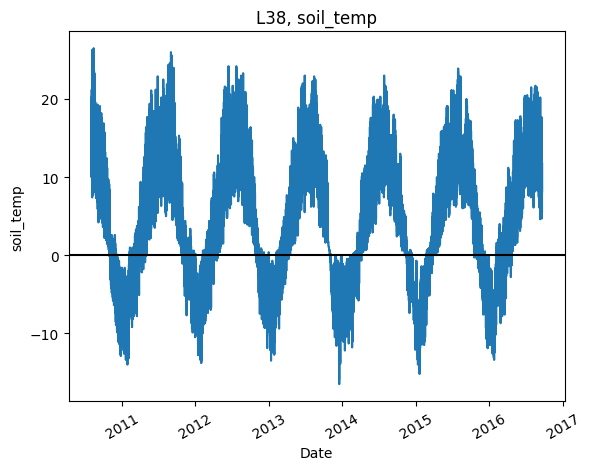

In [33]:
utils.plot(L38_df, long_variable, station=str(dir_L38), form='line')

In [34]:
# export to csv
L38_df.to_csv(cleaned_data_path / f'{str(dir_L38)}_{short_variable}_{max_depth}.csv')

### 3.7 NST-07

In [35]:
# preprocess data
NST_07_df = utils.collect_data(raw_data_path / dir_NST_07, max_depth, short_variable, long_variable)
NST_07_df = utils.create_timestamp_col(NST_07_df)
NST_07_df = utils.convert_nan(NST_07_df, long_variable)

# convert outlier spikes/drops to nan
NST_07_df_outliers = utils.find_outlier_spikes(NST_07_df, long_variable, threshold)
NST_07_df = utils.make_nan_indices(NST_07_df, long_variable, NST_07_df_outliers)

NST_07_df.describe()

,soil_temp
count,73427.000000
mean,5.790998
std,7.292820
min,-36.200000
25%,-0.500000
50%,5.600000
75%,11.900000
max,27.400000


In [36]:
# inspect data
NST_07_df.head()

,soil_temp,ISMN_data_quality,provider_data_quality
UTC_timestamp,,,
2008-06-28 05:00:00+00:00,19.6,G,M
2008-06-28 06:00:00+00:00,20.9,G,M
2008-06-28 07:00:00+00:00,22.3,G,M
2008-06-28 08:00:00+00:00,22.6,G,M
2008-06-28 09:00:00+00:00,21.8,G,M


In [37]:
utils.report_nan_count(NST_07_df, long_variable)

There are 16143 nulls out of 89570 datapoints (0.18% missing).


There's a relatively large proportion of data missing.

In [46]:
NST_07_nan_df = utils.get_nan_gaps(NST_07_df, long_variable)
NST_07_nan_df = utils.add_missed_transitions_col(NST_07_nan_df)
NST_07_nan_df

,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
1,2009-09-26 13:00:00+00:00,2010-05-16 07:00:00+00:00,5563,9.3,14.9,False
2,2013-06-18 13:00:00+00:00,2013-06-30 09:00:00+00:00,285,19.5,19.0,False
3,2016-06-24 09:00:00+00:00,2017-08-25 05:00:00+00:00,10245,11.3,16.1,False
4,2018-07-12 11:00:00+00:00,2018-07-13 00:00:00+00:00,14,16.3,12.7,False
5,2018-07-13 10:00:00+00:00,2018-07-14 10:00:00+00:00,25,20.9,20.2,False
6,2018-09-10 08:00:00+00:00,2018-09-10 14:00:00+00:00,7,13.0,14.2,False
7,2018-09-11 07:00:00+00:00,2018-09-11 12:00:00+00:00,6,13.0,14.6,False


There are three NaN gaps greater than 72 hours in duration:
- 2016/06/24 to 2017/08/25 (10,245 hours)
- 2009/09/26 to 2010/05/16 (5563 hours)
- 2013/06/18 to 2013/06/30 (285 hours)

The first two gaps should've contained F/T transitions.

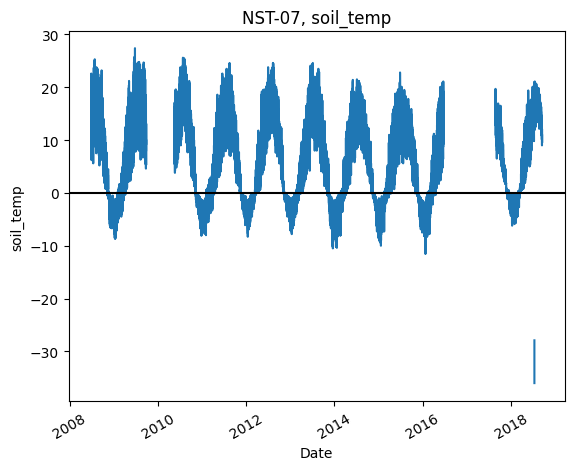

In [38]:
utils.plot(NST_07_df, long_variable, station=str(dir_NST_07), form='line')

The dataset contains 16 F/T transitions. At least four F/T transitions were missed due to large NaN gaps.

There's some odd behaviour in 2018, so zoom in to see what's happening.

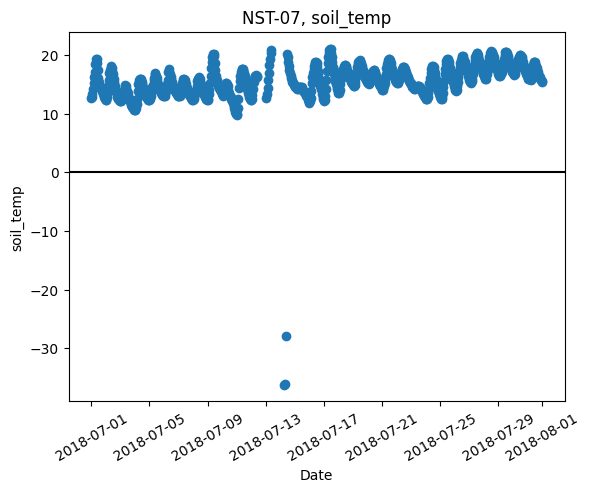

In [39]:
utils.plot(NST_07_df, long_variable, station=str(dir_NST_07), form='scatter', start=datetime.datetime(2018, 7, 1), end=datetime.datetime(2018, 8, 1))

A 50 degree drop in the middle of the summer is likely due to erroneous measurements. The data from 2018/07/14 06:00 to 2018/07/14 10:00 will be converted to NaN.

In [40]:
NST_07_df = utils.make_nan_window(NST_07_df, long_variable, start=datetime.datetime(2018, 7, 14, 6), end=datetime.datetime(2018, 7, 14, 10))

In [41]:
# export to csv
NST_07_df.to_csv(cleaned_data_path / f'{str(dir_NST_07)}_{short_variable}_{max_depth}.csv')

### 3.8 NST-09

In [48]:
# preprocess data
NST_09_df = utils.collect_data(raw_data_path / dir_NST_09, max_depth, short_variable, long_variable)
NST_09_df = utils.create_timestamp_col(NST_09_df)
NST_09_df = utils.convert_nan(NST_09_df, long_variable)

# convert outlier spikes/drops to nan
NST_09_df_outliers = utils.find_outlier_spikes(NST_09_df, long_variable, threshold)
NST_09_df = utils.make_nan_indices(NST_09_df, long_variable, NST_09_df_outliers)

NST_09_df.describe()

,soil_temp
count,77408.000000
mean,6.208807
std,8.729682
min,-17.200000
25%,-0.600000
50%,5.900000
75%,13.300000
max,32.200000


In [49]:
# inspect data
NST_09_df.head()

,soil_temp,ISMN_data_quality,provider_data_quality
UTC_timestamp,,,
2008-06-29 03:00:00+00:00,20.0,G,M
2008-06-29 04:00:00+00:00,21.0,G,M
2008-06-29 05:00:00+00:00,21.7,G,M
2008-06-29 06:00:00+00:00,23.5,G,M
2008-06-29 07:00:00+00:00,24.1,G,M


In [50]:
utils.report_nan_count(NST_09_df, long_variable)

There are 18278 nulls out of 95686 datapoints (0.19% missing).


There's a relatively large proportion of data missing.

In [51]:
NST_09_nan_df = utils.get_nan_gaps(NST_09_df, long_variable)
NST_09_nan_df = utils.add_missed_transitions_col(NST_09_nan_df)
NST_09_nan_df

,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2009-09-26 11:00:00+00:00,2010-05-16 05:00:00+00:00,5563,12.8,17.3,False
1,2013-06-18 11:00:00+00:00,2013-06-30 06:00:00+00:00,284,28.1,20.2,False
2,2014-07-19 08:00:00+00:00,2014-10-18 09:00:00+00:00,2186,21.2,8.9,False
3,2016-06-24 06:00:00+00:00,2017-08-25 02:00:00+00:00,10245,13.2,10.0,False


There are only four NaN gaps, all of which are greater than 72 hours in duration:
- 2016/06/24 to 2017/08/25 (10,245 hours)
- 2009/09/26 to 2010/05/16 (5563 hours)
- 2014/07/19 to 2014/10/18 (2186 hours)
- 2013/06/18 to 2013/06/30 (285 hours)

This station has the same NaN gaps as NST-07, except for the 2186-hour duration gap.

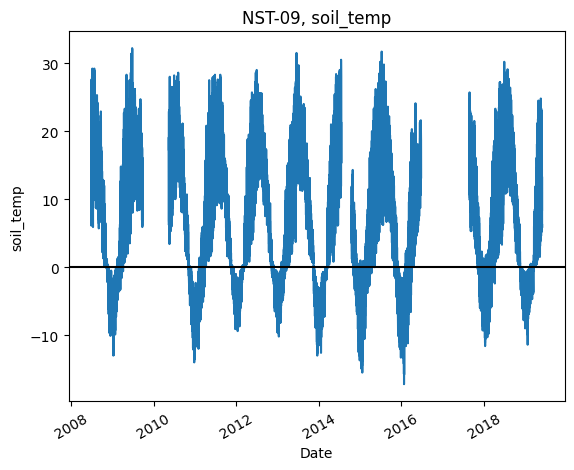

In [52]:
utils.plot(NST_09_df, long_variable, station=str(dir_NST_09), form='line')

The dataset contains 18 F/T transitions. At least four F/T transitions were missed due to large NaN gaps.

In [53]:
# export to csv
NST_09_df.to_csv(cleaned_data_path / f'{str(dir_NST_09)}_{short_variable}_{max_depth}.csv')

### 3.9 SOD012

In [3]:
# preprocess data
SOD012_df = utils.collect_data(raw_data_path / dir_SOD012, max_depth, short_variable, long_variable)
SOD012_df = utils.create_timestamp_col(SOD012_df)
SOD012_df = utils.convert_nan(SOD012_df, long_variable)

# convert outlier spikes/drops to nan
SOD012_df_outliers = utils.find_outlier_spikes(SOD012_df, long_variable, threshold)
SOD012_df = utils.make_nan_indices(SOD012_df, long_variable, SOD012_df_outliers)

SOD012_df.describe()

,soil_temp
count,117366.000000
mean,4.351325
std,6.767497
min,-9.500000
25%,-0.600000
50%,0.600000
75%,10.300000
max,25.900000


In [4]:
# inspect data
SOD012_df.head()

,soil_temp,ISMN_data_quality,provider_data_quality
UTC_timestamp,,,
2011-09-18 00:00:00+00:00,4.9,G,M
2011-09-18 01:00:00+00:00,4.9,G,M
2011-09-18 02:00:00+00:00,4.9,G,M
2011-09-18 03:00:00+00:00,4.7,G,M
2011-09-18 04:00:00+00:00,4.3,G,M


In [5]:
utils.report_nan_count(SOD012_df, long_variable)

There are 8779 nulls out of 126145 datapoints (0.07% missing).


In [6]:
SOD012_nan_df = utils.get_nan_gaps(SOD012_df, long_variable)
SOD012_nan_df = utils.add_missed_transitions_col(SOD012_nan_df)
SOD012_nan_df

,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2011-09-25 00:00:00+00:00,2011-10-15 23:00:00+00:00,504,5.3,0.6,False
1,2011-10-25 07:00:00+00:00,2011-10-25 08:00:00+00:00,2,1.7,2.0,False
2,2011-10-30 00:00:00+00:00,2011-11-19 23:00:00+00:00,504,0.9,-3.3,True
3,2011-11-27 00:00:00+00:00,2011-12-17 23:00:00+00:00,504,-0.5,-0.1,False
4,2012-01-01 00:00:00+00:00,2012-01-14 23:00:00+00:00,336,-0.4,-0.6,False
5,2012-01-29 00:00:00+00:00,2012-02-18 23:00:00+00:00,504,-1.4,-2.7,False
6,2012-02-26 00:00:00+00:00,2012-03-17 23:00:00+00:00,504,-2.2,-2.1,False
7,2012-04-01 00:00:00+00:00,2012-04-14 23:00:00+00:00,336,-1.6,-0.9,False
8,2012-04-29 00:00:00+00:00,2012-05-19 23:00:00+00:00,504,0.0,0.1,False
9,2012-05-27 00:00:00+00:00,2012-06-16 23:00:00+00:00,504,5.1,12.4,False


This dataset contains 21 NaN gaps that are longer than 72 hours in duration. Three of these contain at least one F/T transition.
- 2012/10/28 to 2012/11/17 (504 hours)
- 2012/11/25 to 2012/12/15 (504 hours)
- 2011/10/30 to 2011/11/19 (504 hours)

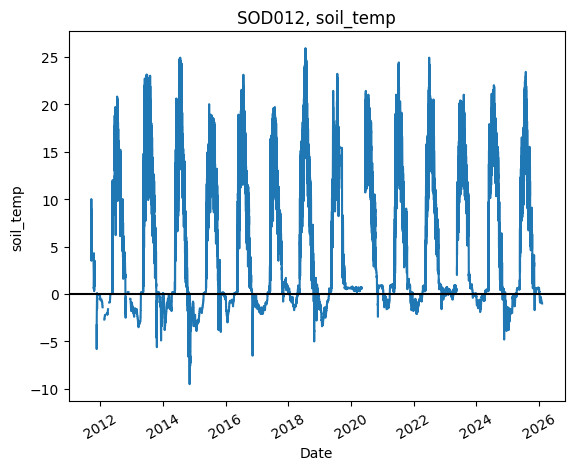

In [13]:
utils.plot(SOD012_df, long_variable, station=str(dir_SOD012), form='line')

It doesn't seem like there's clear F/T transitions. Zoom in to investigate.

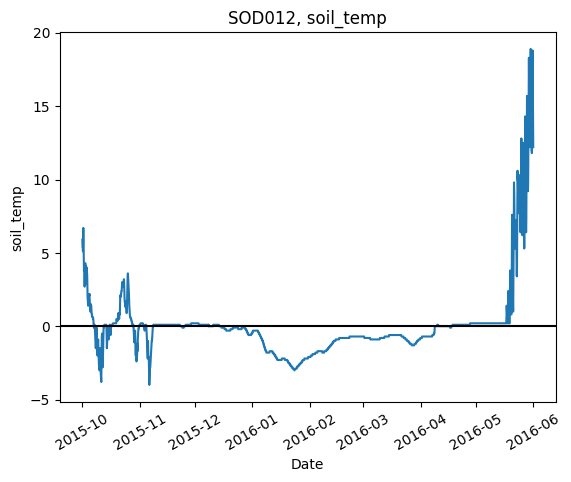

In [15]:
utils.plot(SOD012_df, long_variable, station=str(dir_SOD012), form='line',start=datetime.datetime(2014, 10, 1),  end=datetime.datetime(2015, 6, 1))

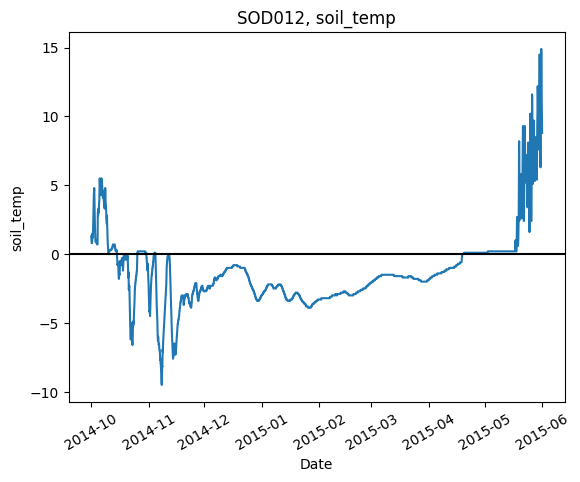

In [17]:
utils.plot(SOD012_df, long_variable, station=str(dir_SOD012), form='line',start=datetime.datetime(2015, 10, 1),  end=datetime.datetime(2016, 6, 1))

Now check the NaN gaps containing possible F/T transitions.

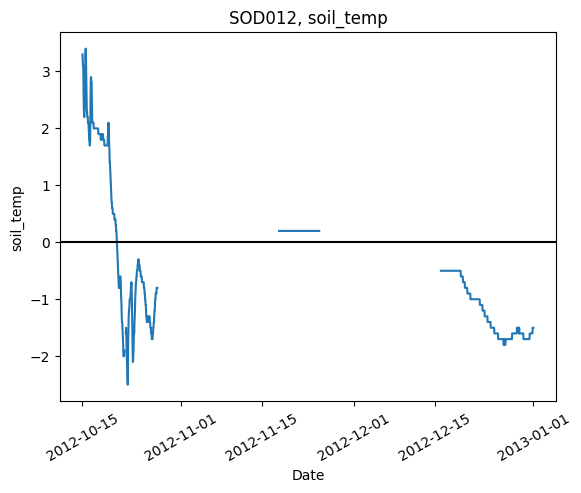

In [19]:
utils.plot(SOD012_df, long_variable, station=str(dir_SOD012), form='line',start=datetime.datetime(2012, 10, 15),  end=datetime.datetime(2013, 1, 1))

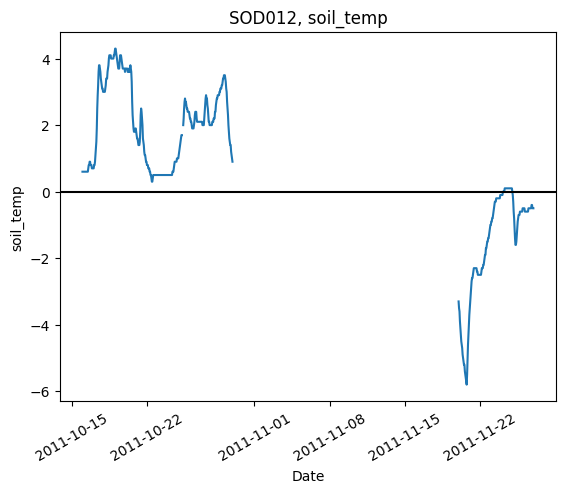

In [20]:
utils.plot(SOD012_df, long_variable, station=str(dir_SOD012), form='line',start=datetime.datetime(2011, 10, 15),  end=datetime.datetime(2011, 12, 1))

This dataset will likely be problematic in making predictions.

In [18]:
# export to csv
SOD012_df.to_csv(cleaned_data_path / f'{str(dir_SOD012)}_{short_variable}_{max_depth}.csv')

### 3.10 SOD103

There are 3271 nulls out of 116737 datapoints (0.03% missing).


,start_timestamp,end_timestamp,gap_length_hours,prev_soil_temp,next_soil_temp,possible_transition
0,2012-10-28 00:00:00+00:00,2012-11-17 23:00:00+00:00,504,0.8,1.3,False
1,2012-11-25 00:00:00+00:00,2012-12-15 23:00:00+00:00,504,1.4,-0.2,True
8,2019-08-18 00:00:00+00:00,2019-08-24 23:00:00+00:00,168,12.1,9.0,False
9,2020-02-11 11:00:00+00:00,2020-02-15 23:00:00+00:00,109,0.7,0.9,False
10,2020-05-07 11:00:00+00:00,2020-06-13 23:00:00+00:00,901,1.1,10.8,False
11,2020-11-18 11:00:00+00:00,2020-11-21 23:00:00+00:00,85,3.9,1.9,False
13,2023-02-10 11:00:00+00:00,2023-02-18 23:00:00+00:00,205,0.8,0.9,False
15,2023-05-15 11:00:00+00:00,2023-05-20 23:00:00+00:00,133,4.9,6.9,False
17,2024-02-22 11:00:00+00:00,2024-03-09 23:00:00+00:00,397,0.5,1.0,False


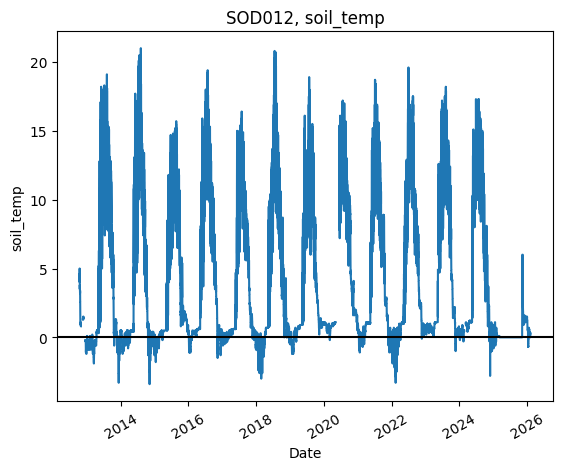

In [30]:
SOD103_df = soil_temp_data_cleaning(data_path=raw_data_path / dir_SOD103,
                                    depth=max_depth,
                                    short_feature=short_variable,
                                    long_feature=long_variable,
                                    station_name=str(dir_SOD012),
                                    temp_threshold=threshold)